In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import joblib

#1️⃣ Data Loading & Exploration

##Load Dataset

In [47]:
# Load dataset
url = "Q:\AI & ML Engineering Course\All Assignment\mod11_assignment\diabetes.csv"

df = pd.read_csv(url)

# Show first 5 rows
df.head()


<>:2: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:2: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\Rizvee\AppData\Local\Temp\ipykernel_13708\1445069601.py:2: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  url = "Q:\AI & ML Engineering Course\All Assignment\mod11_assignment\diabetes.csv"


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#Dataset Shape

In [48]:
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 9)


#Dataset Information

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#Check Missing Values

In [50]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# Statistical **Summary**

In [51]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Check Target Distribution

In [52]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# **Correlation Heatmap**

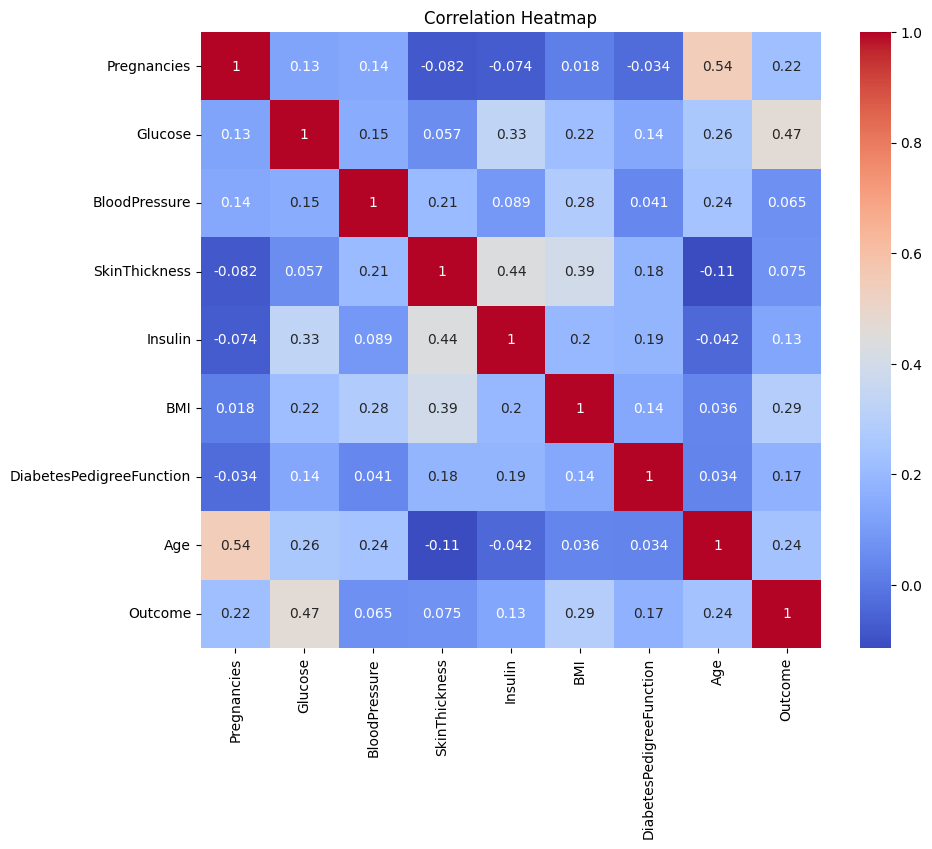

In [53]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#2️⃣ Data Preprocessing
##Separate Features and Target

In [54]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

In [56]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3️⃣ Model Training
Model 1: Logistic Regression

In [57]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

# Model 2: Random Forest

In [58]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

# 4️⃣ Model Evaluation
## Logistic Regression Metrics

In [59]:
print("Logistic Regression Performance")

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, lr_prob))

Logistic Regression Performance
Accuracy: 0.7532467532467533
Precision: 0.6491228070175439
Recall: 0.6727272727272727
F1 Score: 0.6607142857142857
ROC-AUC Score: 0.8146923783287419


# Random Forest Metrics

In [60]:
print("Random Forest Performance")

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_prob))

Random Forest Performance
Accuracy: 0.7207792207792207
Precision: 0.6071428571428571
Recall: 0.6181818181818182
F1 Score: 0.6126126126126126
ROC-AUC Score: 0.8124885215794309


# Classification Reports

In [61]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Random Forest Report
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



# **5️⃣ ROC Curve Visualization**



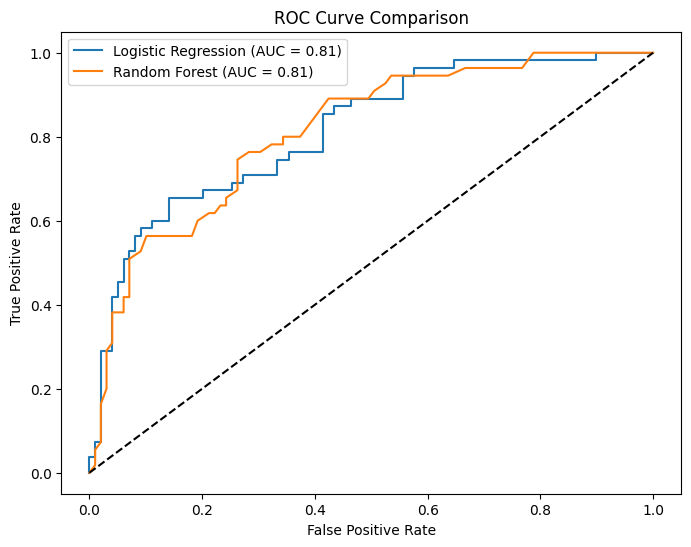

In [62]:
# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.2f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.2f})'
)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

# **6️⃣ Best Model Selection**

In [63]:
lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

if rf_auc > lr_auc:
    best_model = rf_model
    print("Best Model: Random Forest")
else:
    best_model = lr_model
    print("Best Model: Logistic Regression")

Best Model: Logistic Regression


# 7️⃣ Save Best Model

In [64]:
joblib.dump(best_model, 'diabetes_model.pkl')

print("Model saved successfully!")

Model saved successfully!
